In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("husl")

train_path = '../data/raw/train-00000-of-00001.parquet'
valid_path = '../data/raw/validation-00000-of-00001.parquet'
test_path = '../data/raw/test-00000-of-00001.parquet'

df_train = pd.read_parquet(train_path)
df_valid = pd.read_parquet(valid_path)
df_test = pd.read_parquet(test_path)

# Print the shape of the datasets
print(f"Size of Train: {df_train.shape}")
print(f"Size of Valid: {df_valid.shape}")
print(f"Size of Test:  {df_test.shape}")

Size of Train: (54845, 15)
Size of Valid: (7310, 15)
Size of Test:  (7286, 15)


In [2]:
display(df_train.head(3))

# Check the data types of each column
print("\n--- DATA TYPES ---")
df_train.info()

# Check NULL
print("\n--- CHECK FOR NULL VALUES ---")
print(df_train.isnull().sum())

,ID,Sentence,Word_Count,Readability_Level,Readability_Level_19,Readability_Level_7,Readability_Level_5,Readability_Level_3,Annotator,Document,Source,Book,Author,Domain,Text_Class
0,10100290001,مجلة كل الأولاد وكل البنات,5,7-zay,7,2,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
1,10100290002,ماجد,1,1-alif,1,1,1,1,A2,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational
2,10100290003,الأربعاء 21 يناير 1987,4,8-Ha,8,3,2,1,A3,BAREC_Majed_0413_1987_001.txt,Majed,Edition: 413,#,Arts & Humanities,Foundational



--- DATA TYPES ---
<class 'pandas.DataFrame'>
RangeIndex: 54845 entries, 0 to 54844
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   ID                    54845 non-null  int64
 1   Sentence              54845 non-null  str  
 2   Word_Count            54845 non-null  int64
 3   Readability_Level     54845 non-null  str  
 4   Readability_Level_19  54845 non-null  int64
 5   Readability_Level_7   54845 non-null  int64
 6   Readability_Level_5   54845 non-null  int64
 7   Readability_Level_3   54845 non-null  int64
 8   Annotator             54845 non-null  str  
 9   Document              54845 non-null  str  
 10  Source                54845 non-null  str  
 11  Book                  54845 non-null  str  
 12  Author                54845 non-null  str  
 13  Domain                54845 non-null  str  
 14  Text_Class            54845 non-null  str  
dtypes: int64(6), str(9)
memory usage: 18.9 MB

-

In [3]:
# Check for '#NAME?' errors in the 'Sentence' column
name_errors = df_train[df_train['Sentence'] == '#NAME?']
print(f"🚨 Number of sentences with '#NAME?' error: {len(name_errors)} (Accounting for {(len(name_errors)/len(df_train))*100:.2f}%)")

# Check duplicates
duplicates = df_train.duplicated(subset=['Sentence']).sum()
print(f"🔄 Number of duplicate sentences in the training set: {duplicates}")

🚨 Number of sentences with '#NAME?' error: 219 (Accounting for 0.40%)
🔄 Number of duplicate sentences in the training set: 2723


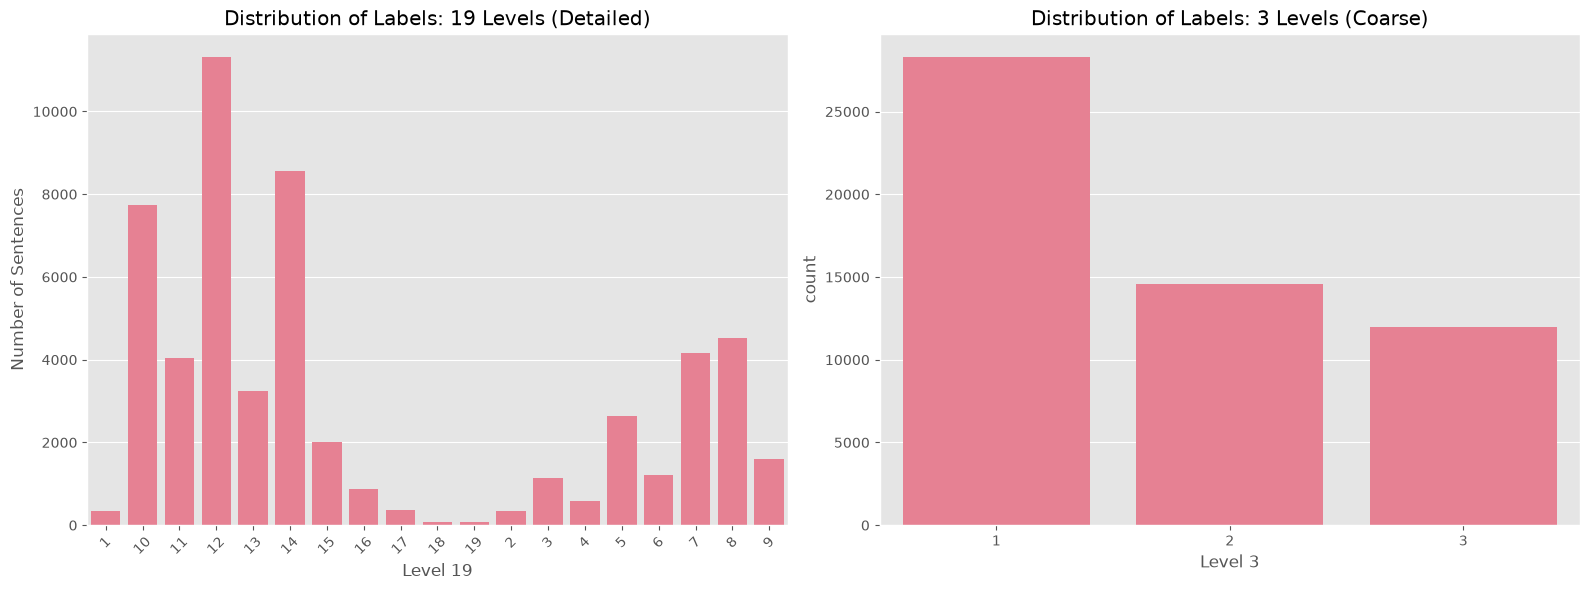

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Level 19
sns.countplot(data=df_train, x='Readability_Level_19', ax=axes[0], order=sorted(df_train['Readability_Level_19'].astype(str).unique()))
axes[0].set_title('Distribution of Labels: 19 Levels (Detailed)')
axes[0].set_xlabel('Level 19')
axes[0].set_ylabel('Number of Sentences')
axes[0].tick_params(axis='x', rotation=45)

# Distribution of Level 3
sns.countplot(data=df_train, x='Readability_Level_3', ax=axes[1], order=sorted(df_train['Readability_Level_3'].astype(str).unique()))
axes[1].set_title('Distribution of Labels: 3 Levels (Coarse)')
axes[1].set_xlabel('Level 3')

plt.tight_layout()
plt.show()

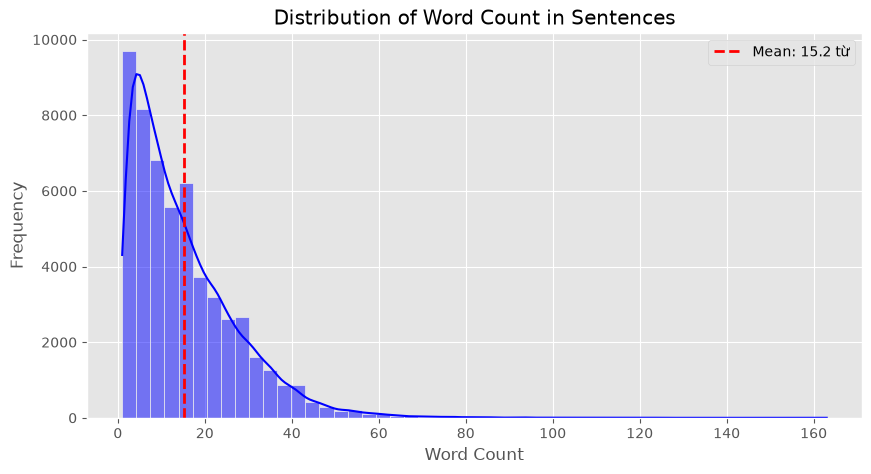

📏 Shortest sentence: 1 words
📏 Longest sentence:  163 words
📏 99% of sentences have a length below: 55 words


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df_train['Word_Count'], bins=50, kde=True, color='blue')

mean_wc = df_train['Word_Count'].mean()
plt.axvline(mean_wc, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {mean_wc:.1f} từ")

plt.title('Distribution of Word Count in Sentences')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"📏 Shortest sentence: {df_train['Word_Count'].min()} words")
print(f"📏 Longest sentence:  {df_train['Word_Count'].max()} words")
print(f"📏 99% of sentences have a length below: {df_train['Word_Count'].quantile(0.99):.0f} words")

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14600\1561185377.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, y='Domain', ax=axes[0], order=df_train['Domain'].value_counts().index, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14600\1561185377.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train[df_train['Source'].isin(top_sources)], y='Source', ax=axes[1], order=top_sources, palette='Set3')


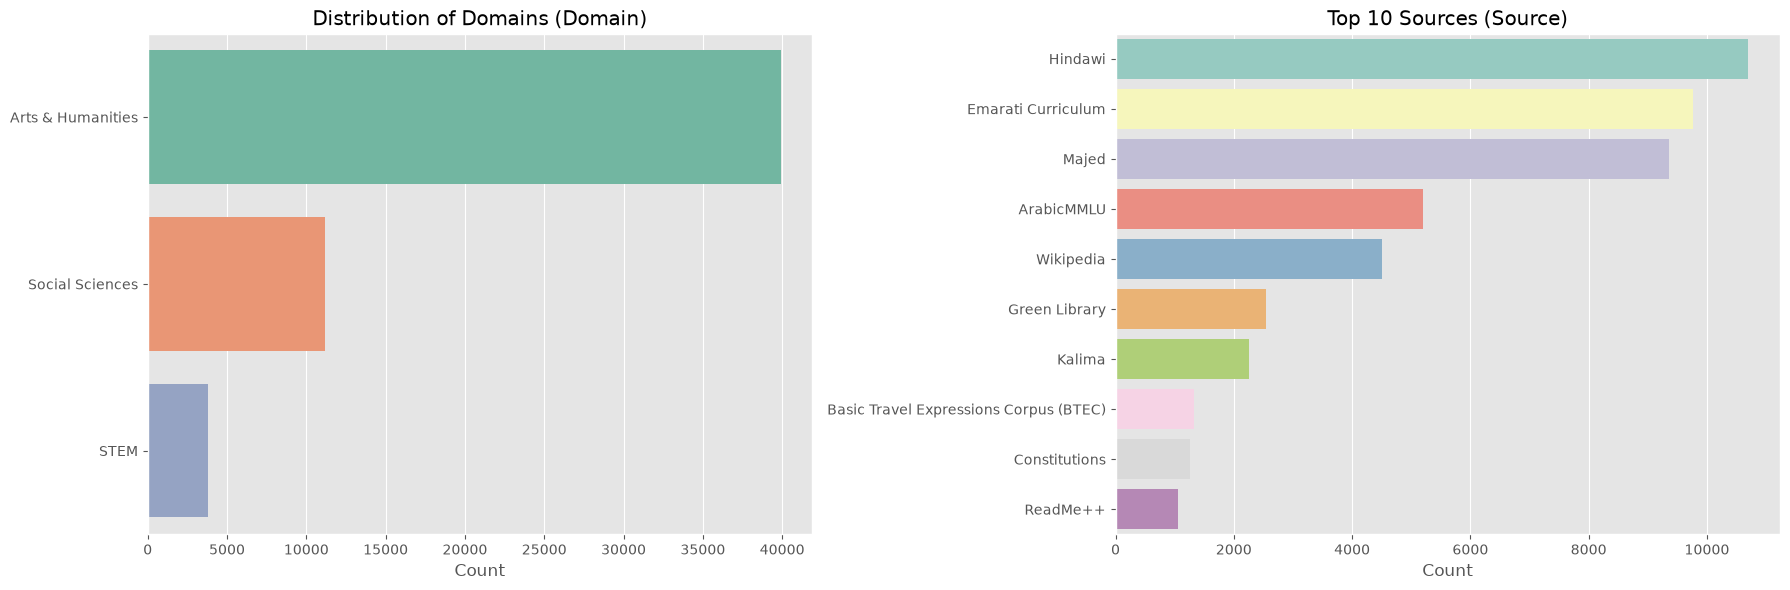

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Domain
sns.countplot(data=df_train, y='Domain', ax=axes[0], order=df_train['Domain'].value_counts().index, palette='Set2')
axes[0].set_title('Distribution of Domains (Domain)')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

# Source
top_sources = df_train['Source'].value_counts().head(10).index
sns.countplot(data=df_train[df_train['Source'].isin(top_sources)], y='Source', ax=axes[1], order=top_sources, palette='Set3')
axes[1].set_title('Top 10 Sources (Source)')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()